In [43]:
import pybaseball
import pandas as pd

In [44]:
# Pull bWAR data from Baseball Reference
war_data = pybaseball.bwar_bat(return_all=True)

# Filter for 2025
war_2025 = war_data[war_data['year_ID'] == 2025]

print(war_2025.shape)
print(war_2025.columns.tolist())

(845, 49)
['name_common', 'age', 'mlb_ID', 'player_ID', 'year_ID', 'team_ID', 'stint_ID', 'lg_ID', 'PA', 'G', 'Inn', 'runs_bat', 'runs_br', 'runs_dp', 'runs_field', 'runs_infield', 'runs_outfield', 'runs_catcher', 'runs_good_plays', 'runs_defense', 'runs_position', 'runs_position_p', 'runs_replacement', 'runs_above_rep', 'runs_above_avg', 'runs_above_avg_off', 'runs_above_avg_def', 'WAA', 'WAA_off', 'WAA_def', 'WAR', 'WAR_def', 'WAR_off', 'WAR_rep', 'salary', 'pitcher', 'teamRpG', 'oppRpG', 'oppRpPA_rep', 'oppRpG_rep', 'pyth_exponent', 'pyth_exponent_rep', 'waa_win_perc', 'waa_win_perc_off', 'waa_win_perc_def', 'waa_win_perc_rep', 'OPS_plus', 'TOB_lg', 'TB_lg']


In [45]:
# Check the key columns we care about
print(war_2025[['name_common', 'team_ID', 'G', 'WAR', 'salary']].head(20))

# Check how many salary values are missing
print("\nMissing salary values:", war_2025['salary'].isna().sum())
print("Total rows:", len(war_2025))

           name_common team_ID    G   WAR      salary
154          Mick Abel     PHI    0   NaN         NaN
225          CJ Abrams     WSN  144  3.43         NaN
261        Bryan Abreu     HOU    1  0.00   3450000.0
292       Wilyer Abreu     BOS  115  3.21         NaN
376      Maximo Acosta     MIA   19 -0.04         NaN
389    Luisangel Acuña     NYM   95  0.56         NaN
398   Ronald Acuña Jr.     ATL   95  2.97  17000000.0
429       Willy Adames     SFG  160  3.73  13142857.0
553       Jordyn Adams     BAL   10 -0.11         NaN
600        Riley Adams     WSN   83  0.36    850000.0
693           Jo Adell     LAA  152  1.19   2100000.0
795         Zach Agnos     COL    1  0.00         NaN
892         Nick Ahmed     TEX    5  0.05         NaN
960        Keegan Akin     BAL    2  0.00   1475000.0
1019      Ozzie Albies     ATL  157  2.10   7000000.0
1060   Kevin Alcántara     CHC   10  0.07         NaN
1075  Sergio Alcántara     SFG    1 -0.08         NaN
1132   Blaze Alexander     A

In [46]:
# Check if missing salary correlates with games played
print(war_2025[war_2025['salary'].isna()]['G'].describe())
print("\nWith salary:")
print(war_2025[war_2025['salary'].notna()]['G'].describe())

count    560.000000
mean      47.923214
std       47.019992
min        0.000000
25%        8.000000
50%       32.500000
75%       74.000000
max      162.000000
Name: G, dtype: float64

With salary:
count    285.000000
mean      84.378947
std       54.622233
min        1.000000
25%       31.000000
50%       93.000000
75%      135.000000
max      162.000000
Name: G, dtype: float64


In [47]:
# Apply our filters first
filtered = war_2025[
    (war_2025['G'] >= 81) &
    (war_2025['WAR'] > 0)
].copy()

print("Players after filtering:", len(filtered))
print("Missing salary after filtering:", filtered['salary'].isna().sum())
print("Have salary after filtering:", filtered['salary'].notna().sum())

Players after filtering: 263
Missing salary after filtering: 112
Have salary after filtering: 151


In [48]:
import subprocess
subprocess.run(['pip', 'install', 'kagglehub'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'kagglehub'], returncode=0, stdout=b'Requirement already satisfied: kagglehub in c:\\users\\cmray\\appdata\\local\\programs\\python\\python310\\lib\\site-packages (1.0.1)\r\nRequirement already satisfied: kagglesdk<1.0,>=0.1.22 in c:\\users\\cmray\\appdata\\local\\programs\\python\\python310\\lib\\site-packages (from kagglehub) (0.1.23)\r\nRequirement already satisfied: packaging in c:\\users\\cmray\\appdata\\local\\programs\\python\\python310\\lib\\site-packages (from kagglehub) (23.2)\r\nRequirement already satisfied: pyyaml in c:\\users\\cmray\\appdata\\local\\programs\\python\\python310\\lib\\site-packages (from kagglehub) (6.0.1)\r\nRequirement already satisfied: requests in c:\\users\\cmray\\appdata\\local\\programs\\python\\python310\\lib\\site-packages (from kagglehub) (2.31.0)\r\nRequirement already satisfied: tqdm in c:\\users\\cmray\\appdata\\local\\programs\\python\\python310\\lib\\site-packages (from kagglehub) (4.66.1)\r\nRequireme

In [49]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("christophertreasure/mlb-player-salaries-2011-2024")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\cmray\.cache\kagglehub\datasets\christophertreasure\mlb-player-salaries-2011-2024\versions\1


In [50]:
import os

salary_path = r'C:\Users\cmray\.cache\kagglehub\datasets\christophertreasure\mlb-player-salaries-2011-2024\versions\1\mlb_salary_data.csv'

salaries = pd.read_csv(salary_path, encoding='latin-1')
print(salaries.shape)
print(salaries.columns.tolist())
print(salaries.head(10))

(13954, 4)
['Year', 'Team', 'Name', 'Salary']
   Year Team               Name      Salary
0  2011  ARI      Kelly Johnson  $5,850,000
1  2011  ARI       Joe Saunders  $5,500,000
2  2011  ARI        Chris Young  $5,200,000
3  2011  ARI       Stephen Drew  $4,650,000
4  2011  ARI       Justin Upton  $4,458,333
5  2011  ARI         J. J. Putz  $4,000,000
6  2011  ARI          Zach Duke  $3,500,000
7  2011  ARI     Miguel Montero  $3,200,000
8  2011  ARI        Melvin Mora  $2,350,000
9  2011  ARI  Armando Galarraga  $2,300,000


In [51]:
# Filter for 2024 and clean salary
salaries_2024 = salaries[salaries['Year']==2024].copy() #copy() essentially makes me a completely independent copy of this filtered result

# Remove $ and commas, convert to numeric
salaries_2024['Salary'] = salaries_2024['Salary'].str.replace('$','', regex=False).str.replace(',','',regex=False).astype(float)
salaries_2024['Name'] = salaries_2024['Name'].str.strip() # Remove leading/trailing whitespace

print(salaries_2024.shape)
print(salaries_2024.head(10))

(1071, 4)
       Year Team               Name      Salary
12883  2024  NYY        Aaron Judge  40000000.0
12884  2024  NYY        Gerrit Cole  36000000.0
12885  2024  NYY  Giancarlo Stanton  32000000.0
12886  2024  NYY          Juan Soto  31000000.0
12887  2024  NYY       Carlos Rodon  27000000.0
12888  2024  NYY     Marcus Stroman  19000000.0
12889  2024  NYY      Anthony Rizzo  17000000.0
12890  2024  NYY     Gleyber Torres  14200000.0
12891  2024  NYY       Alex Verdugo   9200000.0
12892  2024  NYY        Clay Holmes   6050000.0


In [52]:
# Grab 2024 WAR data
war_data = pybaseball.bwar_bat(return_all=True)
war_2024 = war_data[war_data['year_ID'] == 2024].copy()

filtered = war_2024[(war_2024['G'] > 81) & (war_2024['WAR'] > 0)].copy()

print(filtered.shape)
print(filtered[['name_common', 'team_ID', 'G', 'WAR']].head(10))

(263, 49)
            name_common team_ID    G   WAR
224           CJ Abrams     WSN  138  3.33
291        Wilyer Abreu     BOS  132  3.59
428        Willy Adames     MIL  161  3.21
692            Jo Adell     LAA  130  0.79
1018       Ozzie Albies     ATL   99  1.64
1807        Pete Alonso     NYM  162  2.48
1986        Jose Altuve     HOU  153  3.23
2015  Francisco Alvarez     NYM  100  0.81
2117     Yordan Alvarez     HOU  147  5.21
2202       Miguel Amaya     CHC  117  1.95


In [53]:
# Compare name formats
print("WAR names:", filtered['name_common'].head(5).tolist())
print("Salary names:", salaries_2024['Name'].head(5).tolist())

WAR names: ['CJ Abrams', 'Wilyer Abreu', 'Willy Adames', 'Jo Adell', 'Ozzie Albies']
Salary names: ['Aaron Judge', 'Gerrit Cole', 'Giancarlo Stanton', 'Juan Soto', 'Carlos Rodon']


In [54]:
# Normalize accented characters in names
import unicodedata

def remove_accents(text):
    if isinstance(text, str):
        return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    return text
    
salaries_2024['Name'] = salaries_2024['Name'].apply(remove_accents)
filtered['name_common'] = filtered['name_common'].apply(remove_accents)

#Fix additional characters in salaries_2024
salaries_2024['Name'] = salaries_2024['Name'].str.replace('.', '', regex=False)
salaries_2024['Name'] = salaries_2024['Name'].str.replace('-', ' ', regex=False)
salaries_2024['Name'] = salaries_2024['Name'].str.replace("Jr", '', regex=False).str.strip()
salaries_2024['Name'] = salaries_2024['Name'].str.replace("'", '', regex=False)
filtered['name_common'] = filtered['name_common'].str.replace('.', '', regex=False)
filtered['name_common'] = filtered['name_common'].str.replace('-', ' ', regex=False)
filtered['name_common'] = filtered['name_common'].str.replace("Jr", '', regex=False).str.strip()
filtered['name_common'] = filtered['name_common'].str.replace("'", '', regex=False)

# Removing middle initials from both datasets to improve matching
def strip_middle_initial(name):
    parts = name.split()
    if len(parts) == 3 and len(parts[1]) == 1:  # Check for middle initial
        return ' '.join([parts[0], parts[2]])  # Return first and last name only
    return name

salaries_2024['Name'] = salaries_2024['Name'].apply(strip_middle_initial)
filtered['name_common'] = filtered['name_common'].apply(strip_middle_initial)

# Ensure names are in title case for better matching
salaries_2024['Name'] = salaries_2024['Name'].str.title()
filtered['name_common'] = filtered['name_common'].str.title()


Fixing the last remaining name gaps between the two datasets. This was the difference between truncated (nicknames) used and formal names.

In [55]:
nickname_map = {
    'Nathaniel Lowe': 'Nate Lowe',
    'Richie Palacios': 'Richard Palacios',
    'Michael Siani': 'Mike Siani'
}

filtered['name_common'] = filtered['name_common'].replace(nickname_map)

In [56]:
#merge salary and player WAR data
merged = filtered.merge(
    salaries_2024[['Name','Salary']],
    left_on = 'name_common',
    right_on = 'Name',
    how = 'left'
)

print("Total players: ", len(merged))
print("Matched with salary:", merged['Salary'].notna().sum())
print("Missing salary:", merged['Salary'].isna().sum())

# Show the ones that didn't match
missing = merged[merged['Salary'].isna()][['name_common', 'team_ID', 'G', 'WAR']]
print("\nPlayers without salary match:")
print(missing)

Total players:  267
Matched with salary: 260
Missing salary: 7

Players without salary match:
        name_common team_ID    G   WAR
0         Cj Abrams     WSN  138  3.33
73    Tyler Freeman     CLE  118  0.88
87     Nolan Gorman     STL  107  0.47
106   Jose Iglesias     NYM   85  3.04
215   Dominic Smith     BOS   84  0.16
235  Michael Taylor     PIT  113  0.90
239    Abraham Toro     OAK   94  0.61


## Salary Data Gaps — Manual Resolution

The following players were absent from the Kaggle salary dataset, 
likely due to free agent status, team transitions, or pre-arbitration 
minimum contracts not being captured. Salaries were manually sourced 
and will be patched into the merged dataset after matching:

- **CJ Abrams** — $752,400 (Pre-arbitration; forfeited ~$36,435 due to late-season demotion)
- **Tyler Freeman** — $742,000 (Pre-arbitration)
- **Nolan Gorman** — $755,550 (Pre-arbitration)
- **Jose Iglesias** — $1,500,000 (Major league base salary upon contract selection)
- **Dominic Smith** — $740,000 (Pro-rated league minimum, signed May)
- **Michael A. Taylor** — $4,000,000 (1-year free agent contract, signed March)
- **Abraham Toro** — $1,275,000 (Arbitration avoided)

In [57]:
manual_salaries = {
    'Cj Abrams': 752400,
    'Tyler Freeman': 742000,
    'Nolan Gorman': 755550,
    'Jose Iglesias': 1500000,
    'Dominic Smith': 740000,
    'Michael Taylor': 4000000,
    'Abraham Toro': 1275000,
}

for name, salary in manual_salaries.items():
    merged.loc[merged['name_common'] == name, 'Salary'] = salary

In [58]:
print("Total players: ", len(merged))
print("Matched with salary:", merged['Salary'].notna().sum())
print("Missing salary:", merged['Salary'].isna().sum())

# Show the ones that didn't match
missing = merged[merged['Salary'].isna()][['name_common', 'team_ID', 'G', 'WAR']]
print("\nPlayers without salary match:")
print(missing)

Total players:  267
Matched with salary: 267
Missing salary: 0

Players without salary match:
Empty DataFrame
Columns: [name_common, team_ID, G, WAR]
Index: []


In [59]:
print(merged.head(20))
print("\nSalary stats:")
print(merged['Salary'].describe())

          name_common   age    mlb_ID  player_ID  year_ID team_ID  stint_ID  \
0           Cj Abrams  23.0  682928.0  abramcj01     2024     WSN         1   
1        Wilyer Abreu  25.0  677800.0  abreuwi02     2024     BOS         1   
2        Willy Adames  28.0  642715.0  adamewi01     2024     MIL         1   
3            Jo Adell  25.0  666176.0  adelljo01     2024     LAA         1   
4        Ozzie Albies  27.0  645277.0  albieoz01     2024     ATL         1   
5         Pete Alonso  29.0  624413.0  alonspe01     2024     NYM         1   
6         Jose Altuve  34.0  514888.0  altuvjo01     2024     HOU         1   
7   Francisco Alvarez  22.0  682626.0  alvarfr01     2024     NYM         1   
8      Yordan Alvarez  27.0  670541.0  alvaryo01     2024     HOU         1   
9        Miguel Amaya  25.0  665804.0  amayami01     2024     CHC         1   
10      Orlando Arcia  29.0  606115.0  arciaor01     2024     ATL         1   
11      Nolan Arenado  33.0  571448.0  arenano01    

Now that we've worked through salaries_2024 and filtered war data to create a merged datasets with no gaps to impact our analysis, we can now move on to calculating the surplus value of each player, and how they compare across the league. But firstly, what the now merged dataset ultimatly provides 

But first, let's describe what occured above. Once we merged the two datasets, we needed to account for the results that had null values for their respective salary. These null values signified there were gaps between the two datasets that caused some values, in particular salary, not to merge over successfully with eachother. 

The first approach involved normalzing the naming differences between the two datasets. Slight differences - such as an abbreviation with periods or a middle inital - where they were not equally aligned between the two sets, caused a failure in merging the two for those indvidual player records. Lastly, once normalizing names was completed to the best of our abilities, based on functions that provided the missing records, the remaining seven players had null values for their salaries, so in a sense, missing salaries altogether. Rather than removing these records outright, a dictionary was created to fill in these missing gaps after finding the salary values through quick research. Most of these players that had had missing salary values, were due to being a FA at the time the dataset was likely created. 

Now, to see how every player faired in 2024, and the value they brought to the season, based on their play on the field, and the financial cost to the orginization. 

In [60]:
merged['Surplus Value'] = merged['WAR'] * 8000000 - merged['Salary']
print(merged[['name_common', 'WAR', 'Salary', 'Surplus Value']].sort_values(by='Surplus Value', ascending=False).head(20))

           name_common    WAR      Salary  Surplus Value
161      Shohei Ohtani   9.04   2000000.0     70320000.0
65        Jarren Duran   8.99   2081661.0     69838339.0
99    Gunnar Henderson   8.79   2763378.0     67556622.0
262         Bobby Witt   9.62  12855372.0     64104628.0
112        Aaron Judge  10.90  40000000.0     47200000.0
199       Brent Rooker   5.55   1437804.0     42962196.0
135        Ketel Marte   6.75  13000000.0     41000000.0
88        Riley Greene   5.28   1284146.0     40955854.0
54     Elly De La Cruz   5.21   1603210.0     40076790.0
260         Masyn Winn   5.09   1202146.0     39517854.0
155          Zach Neto   5.06   1192551.0     39287449.0
38        Matt Chapman   7.07  18000000.0     38560000.0
183       Jose Ramirez   6.82  17000000.0     37560000.0
44   William Contreras   4.96   2489074.0     37190926.0
243       Brice Turang   4.76   1116214.0     36963786.0
181        Cal Raleigh   4.64   1508720.0     35611280.0
145    Jackson Merrill   4.46  

Rough draft of findings:
Many of the players in the highest Surplus Value have a salary less than 10 million in 2024.

It would seem to me, although it would need further investigation, that many of the players listed are in their arbitration era of ball, or pre-arbitration - hard to determine. But Henderson, duran, rooker, greene, cruz, winn, neto, and so forth are pretty good players in 2026 and are relatively new superstars, but also, this dataset was in 2024, so they would have been even a little younger.

I might be wrong, but I'm not seeing any 1B or 2B listed.

In [61]:
print(merged.groupby('team_ID')['Surplus Value'].sum().sort_values(ascending=False))

team_ID
ARI    195220835.0
BAL    185797228.0
BOS    185011772.0
LAD    172251366.0
MIL    164655165.0
KCR    137074309.0
CLE    135570691.0
DET    124135800.0
OAK    122805291.0
SEA    121544134.0
TOR    120857988.0
HOU    119165238.0
SDP    114946424.0
SFG    111833291.0
TEX    106737913.0
WSN    103810337.0
TBR    100943988.0
CHC     93765593.0
NYY     93436472.0
COL     91762591.0
LAA     88652559.0
CIN     88391790.0
STL     80767682.0
PHI     73961509.0
NYM     73349633.0
MIN     69256780.0
PIT     64716196.0
ATL     61572931.0
MIA     49079938.0
CHW     -7749540.0
Name: Surplus Value, dtype: float64


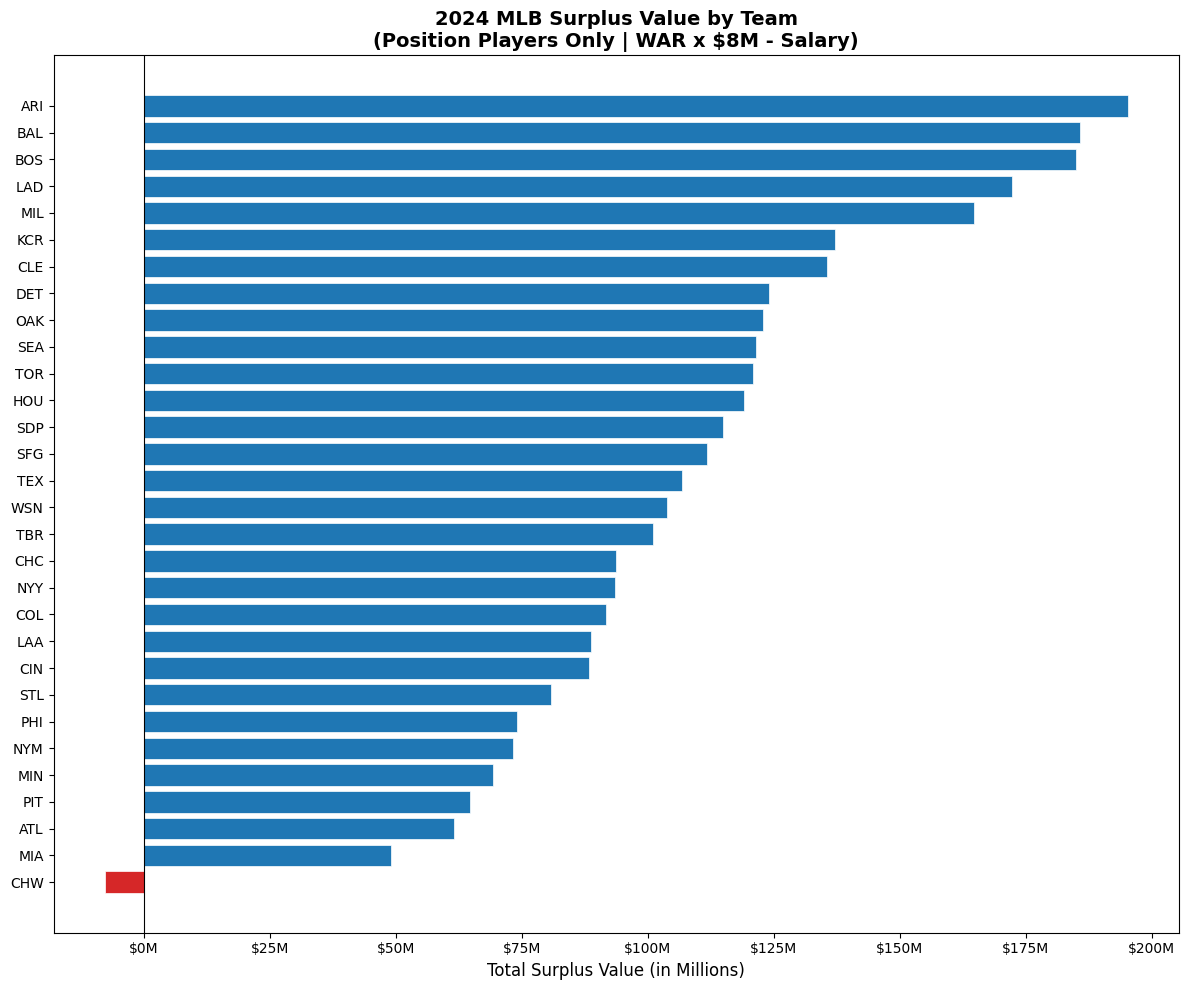

In [64]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

team_surplus = merged.groupby('team_ID')['Surplus Value'].sum().sort_values(ascending=True)

colors = ['#d62728' if v < 0 else '#1f77b4' for v in team_surplus.values]

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(team_surplus.index, team_surplus.values / 1_000_000, color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax.set_xlabel('Total Surplus Value (in Millions)', fontsize=12)
ax.set_title('2024 MLB Surplus Value by Team\n(Position Players Only | WAR x $8M - Salary)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('surplus_value_2024.png', dpi=150, bbox_inches='tight')
plt.show()
